In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, average_precision_score, auc, RocCurveDisplay
import os

In [2]:
train_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_train_seqs_new.csv")
val_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_val_seqs_validation.csv")

In [3]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY-"

def extract_features(sequence):
    sequence = sequence.upper()
    seq_len = len(sequence)
    counts = {aa: sequence.count(aa)/seq_len for aa in amino_acids}
    return counts

In [4]:
x_train = pd.DataFrame([extract_features(seq) for seq in train_df["Aligned Sequence"]])
y_train = train_df["Label"].values
x_val = pd.DataFrame([extract_features(seq) for seq in val_df["Aligned Sequence"]])
y_val = val_df["Label"].values

In [ ]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12, 
    min_samples_leaf=3, 
    min_samples_split=10,
    n_jobs=-1, 
    max_features="sqrt", 
    class_weight="balanced", 
    random_state=42 
    )
clf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [6]:
y_pred = clf.predict(x_val)
y_scores = clf.predict_proba(x_val)[:, 1]
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_val, clf.predict_proba(x_val)[:, 1]))

Accuracy: 0.5908088235294118
Precision: 0.543832428238945
Recall: 0.5717781402936378
F1 Score: 0.557455268389662

Confusion Matrix:
 [[906 588]
 [525 701]]

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.61      0.62      1494
           1       0.54      0.57      0.56      1226

    accuracy                           0.59      2720
   macro avg       0.59      0.59      0.59      2720
weighted avg       0.59      0.59      0.59      2720


ROC AUC Score: 0.6232537545505568


In [ ]:
y_train_pred = clf.predict(x_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_pred))


Training Accuracy: 0.6906818599522146
Validation Accuracy: 0.5908088235294118


In [8]:
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
ap = average_precision_score(y_val, y_scores)
print("Average precision:", ap)

Average precision: 0.5676567726384903


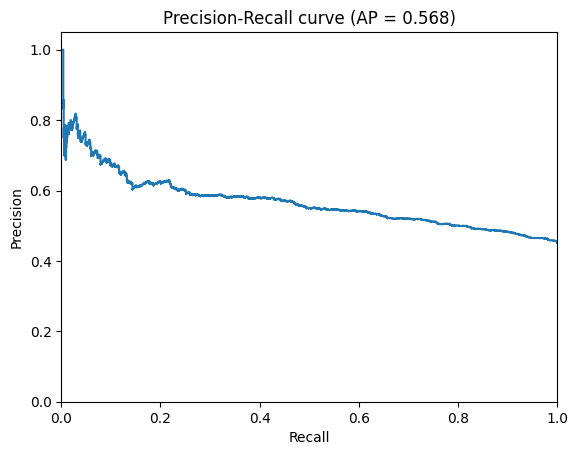

In [9]:
plt.figure()
plt.step(recall, precision, where="post")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curve (AP = {ap:.3f})")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

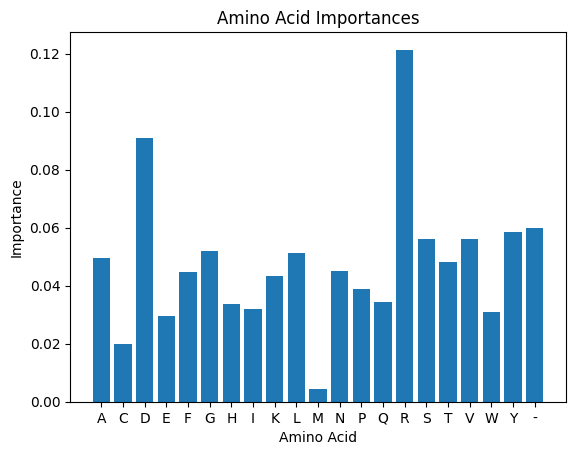

In [10]:
importances = clf.feature_importances_
plt.bar(list(amino_acids), importances)
plt.xlabel('Amino Acid')
plt.ylabel('Importance')
plt.title('Amino Acid Importances')
plt.show()

Test set evaluation

In [11]:
test_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_test_seqs_new.csv")
x_test = pd.DataFrame([extract_features(seq) for seq in test_df["Aligned Sequence"]])
y_test = test_df["Label"].values
clusters_test = test_df["Cluster_number"].values

In [12]:
val_test_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_val_seqs_test.csv")
x_test_val = pd.DataFrame([extract_features(seq) for seq in val_test_df["Aligned Sequence"]])
y_test_val = val_test_df["Label"].values
clusters_test_val = val_test_df["Cluster_number"].values

In [ ]:
def evaluate_split(clf, x, y, split_name="Test"):
    y_scores = clf.predict_proba(x)[:, 1]
    y_pred = (y_scores >= 0.5).astype(int)

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    cm = confusion_matrix(y, y_pred)

    roc_auc = roc_auc_score(y, y_scores)
    p, r, _ = precision_recall_curve(y, y_scores)
    pr_auc = auc(r, p)

    print(f"\n================ FULL {split_name.upper()} SET ================\n")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1:        {f1:.3f}")
    print("\nConfusion matrix:")
    print(cm)
    print(f"\nROC-AUC:   {roc_auc:.3f}")
    print(f"PR-AUC:    {pr_auc:.3f}")

    return {
        "y_scores": y_scores,
        "y_pred": y_pred,
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
        "cm": cm,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }

In [14]:

def evaluate_at_k(y_true, y_scores, clusters, k=100, split_name="Test"):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)
    clusters = np.asarray(clusters)

    assert len(y_true) == len(y_scores), "y_true and y_scores must have same length"
    assert len(y_true) == len(clusters), "y_true and clusters must have same length"

    k = min(k, len(y_true))
    top_idx = np.argsort(y_scores)[::-1][:k]
    y_topk = y_true[top_idx]

    # precision@k
    precision_k = y_topk.sum() / k
    total_positives = y_true.sum()

    # precision@1000
    k_1000 = min(1000, len(y_true))
    top_idx_1000 = np.argsort(y_scores)[::-1][:k_1000]
    precision_1000 = y_true[top_idx_1000].sum() / k_1000

    # ef@k
    positive_rate = total_positives / len(y_true)
    ef_k = (precision_k / positive_rate) if positive_rate > 0 else np.nan

    # diversity@k
    diversity_k = len(np.unique(clusters[top_idx]))

    # normalized diversity@k
    total_unique_clusters = len(np.unique(clusters))
    normalized_diversity_k = (
        diversity_k / total_unique_clusters if total_unique_clusters > 0 else np.nan
    )
    
    print(f"\n================ {split_name.upper()} @ {k} ================\n")

    print(f"Precision@{k}:            {precision_k:.3f}")
    print(f"Precision@1000:           {precision_1000:.3f}")
    print(f"EF@{k}:                   {ef_k:.3f}" if not np.isnan(ef_k) else f"EF@{k}:NaN")

    print(f"Diversity@{k}:            {diversity_k}")
    print(f"Normalized Diversity@{k}: {normalized_diversity_k:.3f}" 
      if not np.isnan(normalized_diversity_k) 
      else f"Normalized Diversity@{k}: NaN")

    return {
        "top_idx": top_idx,
        f"precision@{k}": precision_k,
        f"precision@1000": precision_1000,
        f"ef@{k}": ef_k,
        f"diversity@{k}": diversity_k,
        f"normalized_diversity@{k}": normalized_diversity_k
    }


In [15]:
test_results = evaluate_split(clf, x_test, y_test, split_name="Test")
test_at_100 = evaluate_at_k(y_test, test_results["y_scores"], clusters_test, k=100, split_name="Test")

val_test_results = evaluate_split(clf, x_test_val, y_test_val, split_name="Validation")
val_test_at_100 = evaluate_at_k(y_test_val, val_test_results["y_scores"], clusters_test_val, k=100, split_name="Validation")


================ FULL TEST SET ================

Accuracy:  0.582
Precision: 0.571
Recall:    0.560
F1:        0.565

Confusion matrix:
[[11367  7464]
 [ 7820  9938]]

ROC-AUC:   0.608
PR-AUC:    0.594

================ TEST @ 100 ================

Precision@100:            0.800
Precision@1000:           0.749
EF@100:                   1.648
Diversity@100:            96
Normalized Diversity@100: 0.005

================ FULL VALIDATION SET ================

Accuracy:  0.572
Precision: 0.525
Recall:    0.538
F1:        0.531

Confusion matrix:
[[898 597]
 [566 659]]

ROC-AUC:   0.611
PR-AUC:    0.561

================ VALIDATION @ 100 ================

Precision@100:            0.680
Precision@1000:           0.543
EF@100:                   1.510
Diversity@100:            96
Normalized Diversity@100: 0.043


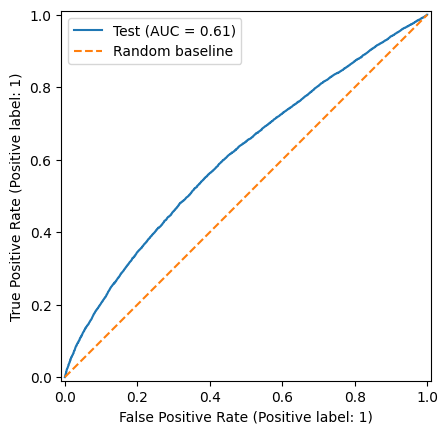

In [16]:
RocCurveDisplay.from_predictions(y_test, test_results["y_scores"], name="Test")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.legend()
plt.show()


In [ ]:

model_name = "RF_Full_Sequence"
seq_sim = 70

metrics_row = pd.DataFrame({
    "Model": [model_name],
    "Sequence_Similarity": [seq_sim],
    "Accuracy_test": [test_results["acc"]],
    "Precision_test": [test_results["prec"]],
    "Recall_test": [test_results["rec"]],
    "F1_test": [test_results["f1"]],
    "ROC_AUC_test": [test_results["roc_auc"]],
    "PR_AUC_test": [test_results["pr_auc"]],

    "Precision@100_test": [test_at_100["precision@100"]],
    "Precision@1000_test": [test_at_100["precision@1000"]],
    "EF@100_test": [test_at_100["ef@100"]],
    "Diversity@100_test": [test_at_100["diversity@100"]],
    "Normalized_Diversity@100_test": [test_at_100["normalized_diversity@100"]],

    "Precision@100_val": [val_test_at_100["precision@100"]],
    "Precision@1000_val": [val_test_at_100["precision@1000"]],
    "EF@100_val": [val_test_at_100["ef@100"]],
    "Diversity@100_val": [val_test_at_100["diversity@100"]],
    "Normalized_Diversity@100_val": [val_test_at_100["normalized_diversity@100"]],

    "N_test": [len(y_test)],
    "N_val": [len(y_test_val)]
})

metrics_file = r"D:\Thesis EGFR Round 3\Baseline Models\Results\metrics_all_models_70.csv"

metrics_row.to_csv(
    metrics_file,
    mode='a',
    header=not os.path.exists(metrics_file),
    index=False
)

print("Metrics saved.")

Metrics saved.


In [19]:
def get_topk_df(df, y_true, y_scores, y_pred, top_idx):
    topk_df = df.iloc[top_idx].copy().assign(
        y_true=y_true[top_idx],
        pred_score=y_scores[top_idx],
        pred_label=y_pred[top_idx]
    )
    tp_topk_df = topk_df[
        (topk_df["y_true"] == 1) & (topk_df["pred_label"] == 1)
    ].copy()
    return tp_topk_df


In [20]:
tp_top100_df = get_topk_df(test_df, y_test, test_results["y_scores"], test_results["y_pred"], test_at_100["top_idx"])

In [24]:
export_df = tp_top100_df[[
    "Cluster_number",
    "Nanobody_id",
    "Label",
    "pred_label",
    "pred_score",
    "Sequence",
    "CDR1",
    "CDR2",
    "CDR3",
    "CDR1 aligned",
    "CDR2 aligned",
    "CDR3 aligned",
    "Aligned Sequence",
    "CDR_sequence"
]]


In [22]:
export_df.to_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\Predictions\regularized_count_full_sequence.csv", index=False)
print("Saved only confident predictions to confident_predictions.csv")
print("Number of confident predictions:", len(export_df))


Saved only confident predictions to confident_predictions.csv
Number of confident predictions: 80
